<a href="https://colab.research.google.com/github/amithdhage-sustainability/hill-of-towie-scada-analysis/blob/main/HillOfTowie_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('drive/MyDrive/Wind turbine/tblSCTurbine_2025_01.csv')

In [4]:
df.head()

,TimeStamp,StationId,wtc_CurTime_endvalue,wtc_SecAnemo_min,wtc_SecAnemo_max,wtc_SecAnemo_mean,wtc_SecAnemo_stddev,wtc_YawPos_min,wtc_YawPos_max,wtc_YawPos_mean,...,wtc_BoostAct_max,wtc_BoostAct_mean,wtc_BoostAct_stddev,wtc_ActualWindDirection_min,wtc_ActualWindDirection_max,wtc_ActualWindDirection_mean,wtc_ActualWindDirection_stddev,wtc_WTOperSt_min,wtc_WTOperSt_max,wtc_WTOperSt_endvalue
0,2025-01-01 00:00:00,2304510,2024-12-31 23:59:58,9.80,20.570000,14.62702,1.689839,268.799988,275.500000,272.159912,...,0.0,0.0,0.0,251.000000,303.200012,273.865387,10.473000,0,0,0
1,2025-01-01 00:00:00,2304511,2024-12-31 23:59:58,8.95,19.150000,13.05362,1.642682,237.300003,245.100006,239.708405,...,0.0,0.0,0.0,210.500000,271.000000,241.686798,11.395720,0,0,0
2,2025-01-01 00:00:00,2304512,2024-12-31 23:59:58,9.62,20.830000,14.46624,1.924990,248.699997,254.600006,252.036606,...,0.0,0.0,0.0,224.800003,285.899994,253.524704,9.083889,0,0,0
3,2025-01-01 00:00:00,2304513,2024-12-31 23:59:59,8.48,22.530001,14.94520,1.681559,251.600006,259.799988,255.515396,...,0.0,0.0,0.0,235.199997,293.399994,257.030609,8.340936,0,0,0
4,2025-01-01 00:00:00,2304514,2024-12-31 23:59:58,8.87,20.629999,14.05153,1.751299,224.899994,235.300003,230.949005,...,0.0,0.0,0.0,203.600006,265.399994,232.339798,11.225720,0,0,0


In [5]:
df_wind = df[['TimeStamp', 'StationId', 'wtc_AcWindSp_mean']].copy()
df_wind.head()

,TimeStamp,StationId,wtc_AcWindSp_mean
0,2025-01-01 00:00:00,2304510,13.51901
1,2025-01-01 00:00:00,2304511,11.67991
2,2025-01-01 00:00:00,2304512,13.25155
3,2025-01-01 00:00:00,2304513,13.82041
4,2025-01-01 00:00:00,2304514,12.39033


In [6]:
df.shape

(93765, 96)

In [7]:
df_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93765 entries, 0 to 93764
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TimeStamp          93765 non-null  object 
 1   StationId          93765 non-null  int64  
 2   wtc_AcWindSp_mean  93765 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ MB


In [8]:
df_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93765 entries, 0 to 93764
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TimeStamp          93765 non-null  object 
 1   StationId          93765 non-null  int64  
 2   wtc_AcWindSp_mean  93765 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ MB


In [9]:
df_wind['TimeStamp'] = pd.to_datetime(
    df_wind['TimeStamp'],
    format='%Y-%m-%d %H:%M:%S'
)
df_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93765 entries, 0 to 93764
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TimeStamp          93765 non-null  datetime64[ns]
 1   StationId          93765 non-null  int64         
 2   wtc_AcWindSp_mean  93765 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.1 MB


In [10]:
print('Number of turbines', df_wind['StationId'].nunique())
print('Number of timestamps', df_wind['TimeStamp'].nunique())

print('First time stamp', df_wind['TimeStamp'].min())
print('Last time stamp', df_wind['TimeStamp'].max())

Number of turbines 21
Number of timestamps 4465
First time stamp 2025-01-01 00:00:00
Last time stamp 2025-02-01 00:00:00


In [11]:
df_wind['TimeStamp'].drop_duplicates().sort_values().diff().value_counts()

,count
TimeStamp,
0 days 00:10:00,4464


In [12]:
df_wind = df_wind[df_wind['TimeStamp'] > '2025-01-01 00:00:00'].copy()

In [13]:
df_wind.shape

(93744, 3)

In [14]:
df_wind['wtc_AcWindSp_mean'].describe()

,wtc_AcWindSp_mean
count,93744.000000
mean,7.241482
std,4.067850
min,0.088868
25%,4.209396
50%,6.683253
75%,9.697658
max,28.744160


In [15]:
df_wind.groupby('StationId').size()

,0
StationId,
2304510,4464
2304511,4464
2304512,4464
2304513,4464
2304514,4464
2304515,4464
2304516,4464
2304517,4464
2304518,4464


In [16]:
df_wind.duplicated(subset=['TimeStamp', 'StationId']).sum()

np.int64(0)

In [17]:
df_wind.groupby('StationId')['wtc_AcWindSp_mean'].describe()

,count,mean,std,min,25%,50%,75%,max
StationId,,,,,,,,
2304510,4464.0,7.319565,3.905852,0.307377,4.464101,6.846931,9.879862,24.393061
2304511,4464.0,6.641375,3.630109,0.285153,4.032420,6.181552,8.943043,22.275000
2304512,4464.0,7.485689,4.011872,0.361819,4.467389,7.052167,10.168030,26.021339
2304513,4464.0,7.483945,4.142185,0.204968,4.478977,6.969977,10.071525,27.135929
2304514,4464.0,6.961026,3.716795,0.334176,4.295315,6.537643,9.064251,24.800970
2304515,4464.0,6.140379,3.557552,0.158784,3.500125,5.597842,7.971199,23.815901
2304516,4464.0,8.134596,4.344252,0.198542,4.784406,7.570140,11.193730,25.492451
2304517,4464.0,7.430086,3.945529,0.212105,4.498151,6.863116,9.932774,26.324751
2304518,4464.0,7.559204,4.133604,0.382112,4.427748,6.982906,10.444260,26.592819


In [18]:
rho = 1.25
D = 82
A = math.pi*math.pow(82,2)/4
df_wind['Power'] = 0.5*rho*A*df_wind['wtc_AcWindSp_mean']*df_wind['wtc_AcWindSp_mean']*df_wind['wtc_AcWindSp_mean']
df_wind.head()

,TimeStamp,StationId,wtc_AcWindSp_mean,Power
21,2025-01-01 00:10:00,2304510,11.17708,4.608745e+06
22,2025-01-01 00:10:00,2304511,9.71606,3.027388e+06
23,2025-01-01 00:10:00,2304512,11.30455,4.768233e+06
24,2025-01-01 00:10:00,2304513,11.80236,5.426304e+06
25,2025-01-01 00:10:00,2304514,11.52351,5.050704e+06


In [19]:
df_wind['Energy'] = df_wind['Power']*(1/6)
df_wind.head()

,TimeStamp,StationId,wtc_AcWindSp_mean,Power,Energy
21,2025-01-01 00:10:00,2304510,11.17708,4.608745e+06,768124.202479
22,2025-01-01 00:10:00,2304511,9.71606,3.027388e+06,504564.713427
23,2025-01-01 00:10:00,2304512,11.30455,4.768233e+06,794705.484112
24,2025-01-01 00:10:00,2304513,11.80236,5.426304e+06,904384.018774
25,2025-01-01 00:10:00,2304514,11.52351,5.050704e+06,841784.064155


In [20]:
print('Total energy produced in kWH in Jan',df_wind['Energy'].sum()/1000)

Total energy produced in kWH in Jan 41301913.8374525


In [21]:
turbine_1 = df_wind[df_wind['StationId'] == 2304510]

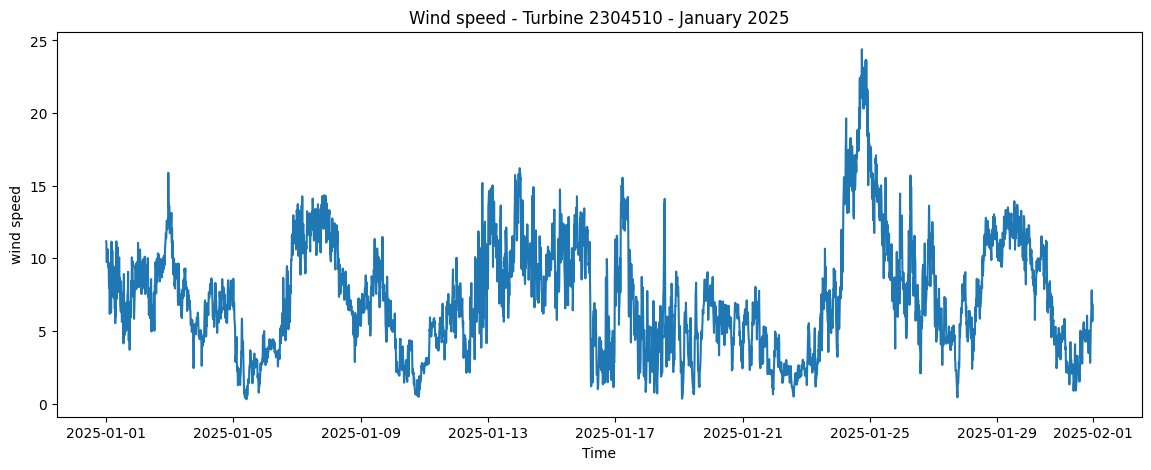

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

plt.plot(turbine_1['TimeStamp'], turbine_1['wtc_AcWindSp_mean'])

plt.xlabel('Time')
plt.ylabel('wind speed')
plt.title('Wind speed - Turbine 2304510 - January 2025')
plt.show()

Text(0.5, 1.0, 'Wind speed distribution - Turbine 2304510 - Jan 2025')

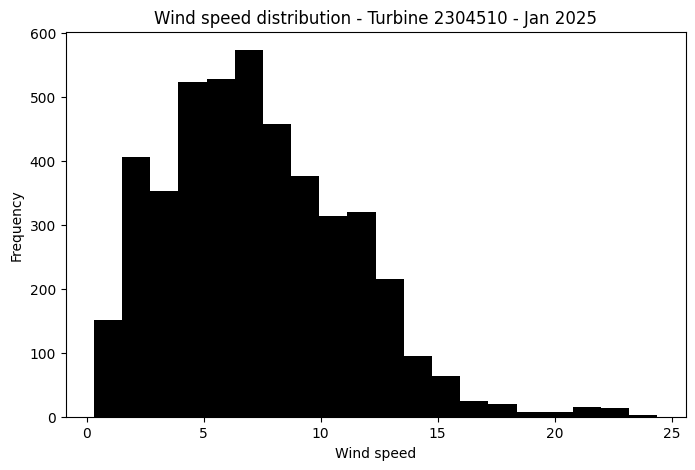

In [23]:
plt.figure(figsize=(8,5))

plt.hist(turbine_1['wtc_AcWindSp_mean'], bins=20, color = 'black')

plt.xlabel('Wind speed')
plt.ylabel('Frequency')
plt.title('Wind speed distribution - Turbine 2304510 - Jan 2025')

In [24]:
mean_wind_speed = df_wind.groupby('StationId')['wtc_AcWindSp_mean'].mean()

mean_wind_speed

,wtc_AcWindSp_mean
StationId,
2304510,7.319565
2304511,6.641375
2304512,7.485689
2304513,7.483945
2304514,6.961026
2304515,6.140379
2304516,8.134596
2304517,7.430086
2304518,7.559204


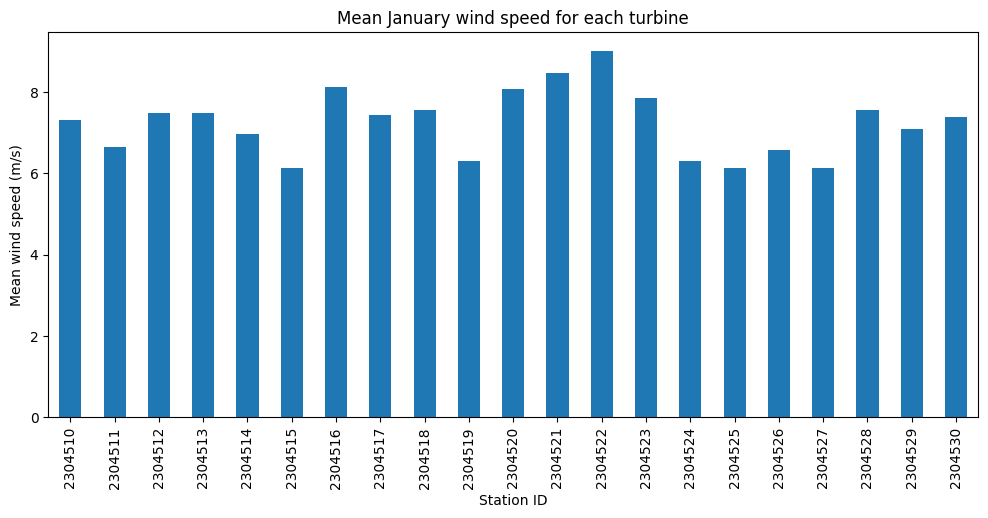

In [25]:
plt.figure(figsize=(12,5))

mean_wind_speed.plot(kind='bar')

plt.xlabel('Station ID')
plt.ylabel('Mean wind speed (m/s)')
plt.title('Mean January wind speed for each turbine')

plt.show()